In [4]:
import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

# 随机种子
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 最终数据设置格式
TARGET_SIZE = (32, 32)
CHANNELS = 3
DTYPE = np.float32

# 路径（相对路径）
BASE_PATH = '../data'
OUTPUT_PATH = './output'

os.makedirs(OUTPUT_PATH, exist_ok=True)

# 整合数据函数
def pillow_integration_worker(split='train'):
    X, y, meta = [], [], []
    domains = ['mnist', 'svhn', 'usps']
    
    start_time = time.time()
    
    for domain in domains:
        folder_path = os.path.join(BASE_PATH, domain, split)
        files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg'))]
        # print(f"Integrating {domain} [{split}]: {len(files)} samples...")
        
        for filename in files:
            # 标签映射
            label = int(filename.split('_label_')[1].split('.')[0])
            img_path = os.path.join(folder_path, filename)
            
            # Pillow整合
            with Image.open(img_path) as img:
                orig_size = img.size
                
                # 统一色彩空间，抹平 Gray/RGB 差异
                img_rgb = img.convert('RGB')
                
                # 统一尺寸
                img_res = img_rgb.resize(TARGET_SIZE, Image.Resampling.BILINEAR)
                
                # 归一化
                img_array = np.array(img_res).astype(DTYPE) / 255.0
                
                X.append(img_array)
                y.append(label)
                meta.append({'src': domain, 'orig': orig_size})

    duration = time.time() - start_time
    X_final = np.array(X)
    y_final = np.array(y)
    
    # 保存为npy文件，供下游模型读取
    np.save(f'{OUTPUT_PATH}/X_{split}_pill.npy', X_final)
    np.save(f'{OUTPUT_PATH}/y_{split}_pill.npy', y_final)
    
    return X_final, y_final, meta, duration

# 分别整合train和test
X_train, y_train, meta_train, time_train = pillow_integration_worker('train')
X_test, y_test, meta_test, time_test = pillow_integration_worker('test')

# 常见性能指标输出
total_imgs = len(X_train) + len(X_test)
total_time = time_train + time_test
print("\n" + "="*35)
print("PILLOW INTEGRATION COMPLETE")
print("="*35)
print(f"Total Images:     {total_imgs}")
print(f"Total Time:       {total_time:.4f}s")
print(f"Avg Throughput:   {total_imgs/total_time:.2f} IPS")
print(f"Train Matrix:     {X_train.shape} | {X_train.nbytes/1e6:.2f} MB")
print(f"Test Matrix:      {X_test.shape} | {X_test.nbytes/1e6:.2f} MB")
print("="*35)

Integrating mnist [train]: 2000 samples...
Integrating svhn [train]: 2000 samples...
Integrating usps [train]: 2000 samples...
Integrating mnist [test]: 500 samples...
Integrating svhn [test]: 500 samples...
Integrating usps [test]: 500 samples...

PILLOW INTEGRATION COMPLETE
Total Images:     7500
Total Time:       4.1443s
Avg Throughput:   1809.73 IPS
Train Matrix:     (6000, 32, 32, 3) | 73.73 MB
Test Matrix:      (1500, 32, 32, 3) | 18.43 MB


Visualizing Integrated Training Set Samples...


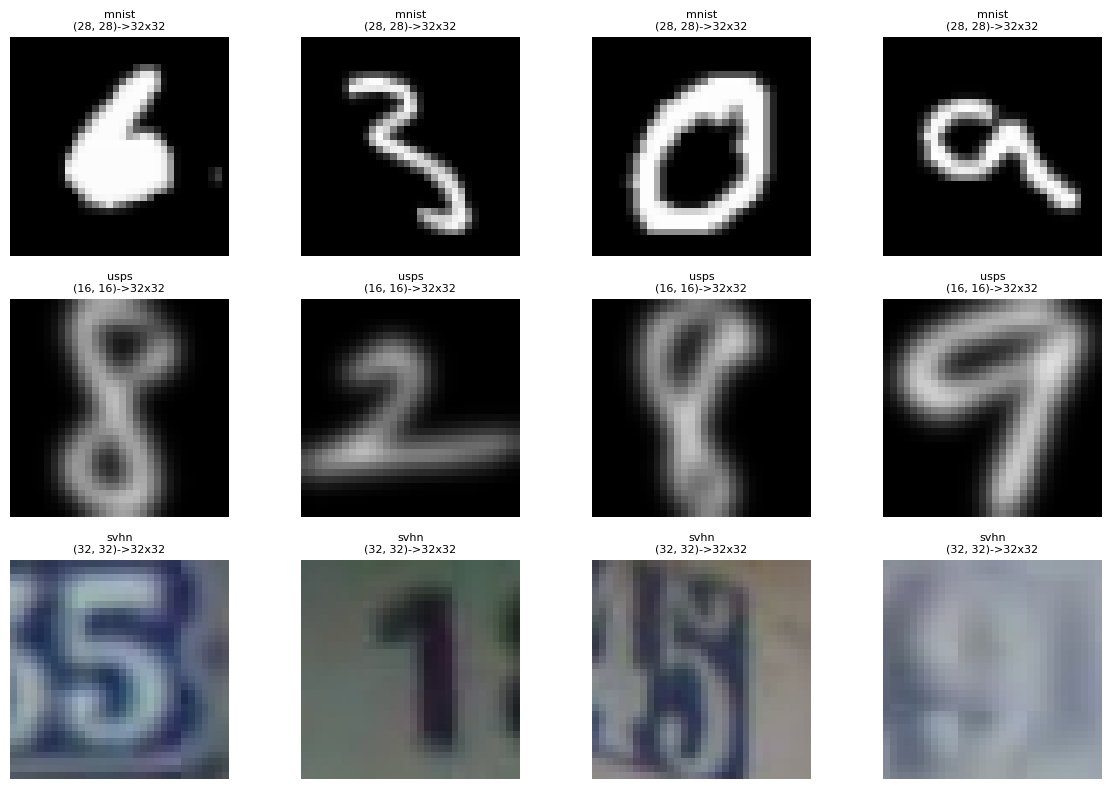

In [5]:
# 挑选部分做可视化，直观感受效果差异
def validate_and_visualize(X, meta, split_name):
    print(f"Visualizing Integrated {split_name} Samples...")
    sources = ['mnist', 'usps', 'svhn']
    n_samples = 4
    fig, axes = plt.subplots(len(sources), n_samples, figsize=(12, 8))
    
    for i, src in enumerate(sources):
        # 筛选对应域的索引
        indices = [idx for idx, m in enumerate(meta) if m['src'] == src]
        subset = random.sample(indices, n_samples)
        
        for j, idx in enumerate(subset):
            axes[i, j].imshow(X[idx])
            axes[i, j].set_title(f"{src}\n{meta[idx]['orig']}->32x32", fontsize=8)
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

# 校验训练集整合效果
validate_and_visualize(X_train, meta_train, "Training Set")

In [7]:
X_train = np.load(f'{OUTPUT_PATH}/X_train_pill.npy')
X_test = np.load(f'{OUTPUT_PATH}/X_test_pill.npy')

# 做归一化以便进行训练
def standardize_data(train_data, test_data):
    
    # 计算均值和标准差
    mean = np.mean(train_data)
    std = np.std(train_data)
    
    # print(f"Train Mean: {mean:.4f} | Train Std: {std:.4f}")
    
    # Z-Score转换
    X_train_std = (train_data - mean) / std
    X_test_std = (test_data - mean) / std
    
    return X_train_std, X_test_std, mean, std

# 执行标准化
X_train_std, X_test_std, final_mean, final_std = standardize_data(X_train, X_test)

# 保存结果
np.save(f'{OUTPUT_PATH}/X_train_std_pill.npy', X_train_std.astype(np.float32))
np.save(f'{OUTPUT_PATH}/X_test_std_pill.npy', X_test_std.astype(np.float32))
np.save(f'{OUTPUT_PATH}/stats_pill.npy', np.array([final_mean, final_std]))


STANDARDIZATION REPORT (PILLOW)
X_train_std Mean: 0.0000 (Should be ~0)
X_train_std Std:  1.0000 (Should be ~1)
X_test_std Mean:  0.0123
Output saved: X_train_std_pill.npy


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json

# 配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10
MODEL_SAVE_PATH = f'{OUTPUT_PATH}/cnn_model_pill.pth'

# 设置PyTorch随机种子
torch.manual_seed(RANDOM_SEED)

# 加载数据(N, C, H, W)
x_train_raw = np.load(f'{OUTPUT_PATH}/X_train_std_pill.npy')
y_train_raw = np.load(f'{OUTPUT_PATH}/y_train_pill.npy')
x_test_raw = np.load(f'{OUTPUT_PATH}/X_test_std_pill.npy')
y_test_raw = np.load(f'{OUTPUT_PATH}/y_test_pill.npy')

def prepare_loader(x, y):
    # 调整维度: (N, 32, 32, 3) -> (N, 3, 32, 32)
    x_pt = torch.tensor(x.transpose(0, 3, 1, 2), dtype=torch.float32)
    y_pt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(x_pt, y_pt), batch_size=BATCH_SIZE, shuffle=True)

train_loader = prepare_loader(x_train_raw, y_train_raw)
test_loader = prepare_loader(x_test_raw, y_test_raw)

# 定义CNN模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 卷积层
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # 全连接层
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 训练
history = {'train_loss': [], 'test_acc': []}
print("Starting CNN Training (Pillow Integrated Data)...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # 测试集评估
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    history['train_loss'].append(running_loss/len(train_loader))
    history['test_acc'].append(acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Test Acc: {acc:.2f}%")

# 保存模型与结果分析指标
torch.save(model.state_dict(), MODEL_SAVE_PATH)
with open(f'{OUTPUT_PATH}/history_pill.json', 'w') as f:
    json.dump(history, f)

print(f"\nModel and metrics saved to {OUTPUT_PATH}")

Starting CNN Training (Pillow Integrated Data)...
Epoch 1/10 | Loss: 1.1742 | Test Acc: 74.73%
Epoch 2/10 | Loss: 0.6123 | Test Acc: 83.27%
Epoch 3/10 | Loss: 0.4510 | Test Acc: 85.20%
Epoch 4/10 | Loss: 0.3173 | Test Acc: 86.80%
Epoch 5/10 | Loss: 0.2363 | Test Acc: 86.40%
Epoch 6/10 | Loss: 0.2049 | Test Acc: 88.00%
Epoch 7/10 | Loss: 0.1586 | Test Acc: 86.93%
Epoch 8/10 | Loss: 0.1267 | Test Acc: 87.87%
Epoch 9/10 | Loss: 0.1106 | Test Acc: 89.00%
Epoch 10/10 | Loss: 0.0971 | Test Acc: 89.53%

Model and metrics saved to ./output
